# This is an End-End project of classifying pictures of cats and dogs

In [ ]:
import numpy as np
# import kagglehub as kh
import pandas as pd
import tensorflow as tf

import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, MaxPooling2D, Flatten, Conv2D, GlobalAveragePooling2D, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import cv2


I0000 00:00:1781632899.416450    3536 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781632900.503857    3536 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781632903.021115    3536 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Now to provide the data to the model, we can write some os path functions to fetch the images one by one to feed the model, but as the number of images are too large, we cant really do that. 


Here as the number of files are very huge, we cant really work with them directly so we use generators. the images are divided into batches and at a time batches of data is processed. 

Here are things we are going to implement: 
1.  gather the dataset from the directory.
2.  normalize it (preprocessing)
3.  Define the model
4. Train the model
5. check the accuracy score
6. plot the values
7. better the  model
8. test the model
9. deploy the model. 

In [2]:
train_ds = keras.utils.image_dataset_from_directory(directory="/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/catsvsdogs/train", labels = 'inferred', label_mode= 'int', batch_size= 32, image_size=(256, 256))
test_ds = keras.utils.image_dataset_from_directory(directory="/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/catsvsdogs/test", labels = 'inferred', label_mode= 'int', batch_size= 32, image_size=(256, 256))
# this step basically extracted all the images efficiently usign the keras generators. 

Found 20000 files belonging to 2 classes.


W0000 00:00:1781632906.218109    3536 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1781632906.221726    3536 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781632906.436660    3536 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Found 5000 files belonging to 2 classes.


In [3]:
import os
print(os.getcwd())
print(os.listdir())

import sys
print(sys.executable)

/mnt/c/Users/Praneeth Tadi/Documents/Coding/Machine Learning/ML Projects/Dog-cat-classify/dog-cat-classify/notebooks
['cats_vs_dogs.ipynb', 'data_fetch.ipynb', 'Dogcat-classifier.keras', 'modeltest.ipynb', 'model_analysis.ipynb', 'Training_histor.csv']
/home/praneeth_tadi/miniconda3/envs/tf-env/bin/python


In [4]:
a = train_ds
print(a)
print("Range of training data: ", np.max(train_ds), np.min(train_ds))

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Range of training data:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [5]:
# Data Processing: Mapping the values to [0, 1] to improve the model performance. 
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
test_ds =test_ds.map(process)

In [6]:
model1 = Sequential()

# convolution layers along with maxpooling
model1.add(Conv2D(32, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))
model1.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model1.add(Conv2D(64, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))
model1.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model1.add(Conv2D(128, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))
model1.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flatten layer. 
model1.add(Flatten())

# Fully connected layer. 

model1.add(Dense(128, activation='relu'))
model1.add(Dense(64, activation='relu'))

# Output layer for classification
model1.add(Dense(1, activation='sigmoid'))

model1.summary()

# Model compilation 
model1.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])




/home/praneeth_tadi/miniconda3/envs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

Running the model#1 now

In [7]:
history = model1.fit(train_ds, epochs= 10, validation_data = test_ds)

Epoch 1/10


I0000 00:00:1781632910.203298    4100 service.cc:153] XLA service 0x7d8af8038f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781632910.203324    4100 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1781632910.258675    4100 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781632910.694403    4100 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1781632910.775116    4100 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2359__.36


  3/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.5278 - loss: 1.1098

I0000 00:00:1781632917.872962    4100 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6097 - loss: 0.6576

I0000 00:00:1781632954.167456    4910 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 4 bytes spill stores, 4 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.6726 - loss: 0.5979 - val_accuracy: 0.7560 - val_loss: 0.5257
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.7765 - loss: 0.4664 - val_accuracy: 0.7840 - val_loss: 0.4604
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.8312 - loss: 0.3706 - val_accuracy: 0.7948 - val_loss: 0.4973
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 239ms/step - accuracy: 0.9019 - loss: 0.2356 - val_accuracy: 0.7878 - val_loss: 0.6947
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.9478 - loss: 0.1345 - val_accuracy: 0.7870 - val_loss: 0.9035
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 160s 257ms/step - accuracy: 0.9693 - loss: 0.0865 - val_accuracy: 0.7668 - val_loss: 1.1238
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step - accuracy: 0.9818 - loss: 0.0531 - val_accuracy: 0.7796 - val_loss: 1.1902
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 181s 289ms/step - accuracy: 0.9848 - loss: 0.0486 - v

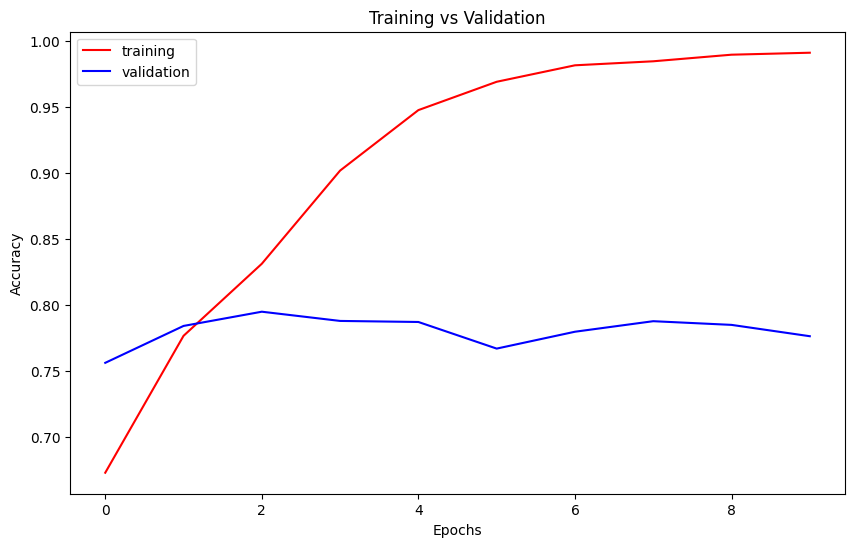

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], color = 'red', label = 'training')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.title("Training vs Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()


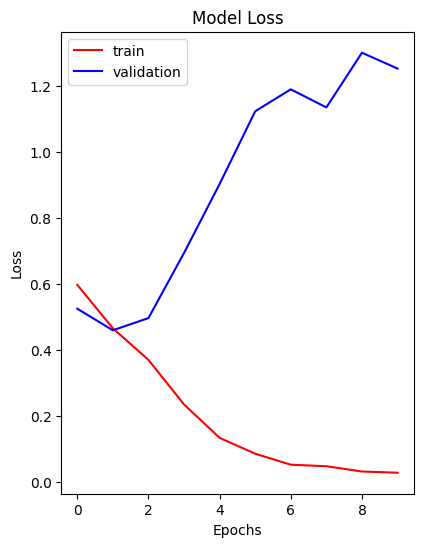

In [9]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

The above plot shows that the model has gone through a lot of overfitting as the training accuracy reaches 1 but validation accuracy is around 0.8

WE first would be deploying this model into an app. Then we would work towards refining it and tuning the model 

We would first be testing the model on an output. 

In [10]:
image = 'Cat.jpg'
image2 = 'Dog.jpg'

In [11]:
if(os.path.exists(image)): 
    test_img = cv2.imread(image)
    # we need to run this line to convert BGR to RGB to show correct colors on the plot. 
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(test_img_rgb) 
    # plt.imshow(test_img)
    plt.show()
    
    # processing the image to tune with the model's input requirement
    test_img_resize = cv2.resize(test_img, (256, 256))
    test_input = test_img_resize.reshape((1, 256, 256, 3))
    
    # scaling the image pixels
    test_input = test_input / 255.0
    
    prediction = model1.predict(test_input)
    print(f"The prediction by the model is : {prediction}")
    if(prediction > 0.5): 
        print("It is a dog")
    else:
        print("It is a cat")
    
     

In [12]:
if(os.path.exists(image2)): 
    test_img = cv2.imread(image2)
    # we need to run this line to convert BGR to RGB to show correct colors on the plot. 
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(test_img_rgb) 
    # plt.imshow(test_img)
    plt.show()
    
    # processing the image to tune with the model's input requirement
    test_img_resize = cv2.resize(test_img, (256, 256))
    test_input = test_img_resize.reshape((1, 256, 256, 3))
    
    # scaling the image pixels
    test_input = test_input / 255.0
    
    prediction = model1.predict(test_input)
    print(f"The prediction by the model is : {prediction}")
    if(prediction > 0.5): 
        print("It is a dog")
    else:
        print("It is a cat")
    

In [13]:
image3 = 'Dog2.jpg'
image4 = 'Cat2.jpg'


In [14]:
if(os.path.exists(image3)): 
    test_img = cv2.imread(image3)
    # we need to run this line to convert BGR to RGB to show correct colors on the plot. 
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(test_img_rgb) 
    # plt.imshow(test_img)
    plt.show()
    
    # processing the image to tune with the model's input requirement
    test_img_resize = cv2.resize(test_img, (256, 256))
    test_input = test_img_resize.reshape((1, 256, 256, 3))
    
    # scaling the image pixels
    test_input = test_input / 255.0
    
    prediction = model1.predict(test_input)
    print(f"The prediction by the model is : {prediction}")
    if(prediction > 0.5): 
        print("It is a dog")
    else:
        print("It is a cat")
if(os.path.exists(image4)): 
    test_img = cv2.imread(image4)
    # we need to run this line to convert BGR to RGB to show correct colors on the plot. 
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(test_img_rgb) 
    # plt.imshow(test_img)
    plt.show()
    
    # processing the image to tune with the model's input requirement
    test_img_resize = cv2.resize(test_img, (256, 256))
    test_input = test_img_resize.reshape((1, 256, 256, 3))
    
    # scaling the image pixels
    test_input = test_input / 255.0
    
    prediction = model1.predict(test_input)
    print(f"The prediction by the model is : {prediction}")
    if(prediction > 0.5): 
        print("It is a dog")
    else:
        print("It is a cat")

As we can see, the model rn works pretty good, but the overfitting problem can further be improved, we are not able to see the issue as the images collected are HD images, with very high clarity, but this model may fail for some bad quality images. 

In [15]:
import sys

print(sys.executable)

/home/praneeth_tadi/miniconda3/envs/tf-env/bin/python


Saving the model before further steps. 

In [16]:
model1.save("Dogcat-classifier.keras")

In [17]:
pd.DataFrame(history.history).to_csv("Training_histor.csv", index = False)


In [19]:
model2 = Sequential()

# convolution layers along with maxpooling
model2.add(Conv2D(32, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))

model2.add(BatchNormalization())
# BatchNormalization()
model2.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model2.add(Conv2D(64, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model2.add(Conv2D(128, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Avg pooling, decreases the number of parameters
model2.add(GlobalAveragePooling2D())

# Fully connected layer. 

model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.4)) # randomly drops the layers to avoid overdependence of layers. 
model2.add(Dense(64, activation='relu'))
model2.add(Dropout(0.4))

# Output layer for classification
model2.add(Dense(1, activation='sigmoid'))
model2.add(EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
))
model2.summary()

# Model compilation 
model2.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

/home/praneeth_tadi/miniconda3/envs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'EarlyStopping' is not defined

In [ ]:
history2 = model2.fit(train_ds, epochs = 10, validation_data = test_ds)


Epoch 1/10


I0000 00:00:1781463546.920808   11680 service.cc:153] XLA service 0x76691803c0b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781463546.920843   11680 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1781463546.959222   11680 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781463547.411817   11680 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1781463547.515622   11680 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3881__.58


  3/625 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.5052 - loss: 0.7478 

I0000 00:00:1781463556.822043   11680 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5786 - loss: 0.6799

I0000 00:00:1781463602.072316   12534 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 4 bytes spill stores, 4 bytes spill loads



625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.6072 - loss: 0.6559 - val_accuracy: 0.6120 - val_loss: 0.6449
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.6725 - loss: 0.6025 - val_accuracy: 0.6526 - val_loss: 0.6582
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.7035 - loss: 0.5706 - val_accuracy: 0.6994 - val_loss: 0.5665
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.7282 - loss: 0.5425 - val_accuracy: 0.6666 - val_loss: 0.6190
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7463 - loss: 0.5193 - val_accuracy: 0.5180 - val_loss: 1.1816
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7636 - loss: 0.4907 - val_accuracy: 0.7296 - val_loss: 0.5437
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.7869 - loss: 0.4549 - val_accuracy: 0.7848 - val_loss: 0.4724
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.8108 - loss: 0.4168 - val_accurac

In [ ]:
pd.DataFrame(history2.history).to_csv("Training_histor2.csv", index = False)

In [ ]:
model2.save("Better_model.keras")

In [27]:
data_aug = Sequential(
   [ keras.layers.RandomFlip("Horizontal"), 
    keras.layers.RandomZoom(0.1), 
    keras.layers.RandomRotation(0.1), 
    keras.layers.RandomContrast(0.1) ]
    
)
model3 = Sequential()
model3.add(data_aug)
# convolution layers along with maxpooling
model3.add(Conv2D(32, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))

model3.add(BatchNormalization())
# BatchNormalization()
model3.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model3.add(Conv2D(64, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model3.add(Conv2D(128, kernel_size=(3, 3), padding = 'valid', activation  = 'relu', input_shape = (256, 256, 3)))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Avg pooling, decreases the number of parameters
model3.add(GlobalAveragePooling2D())

# Fully connected layer. 

model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.3)) # randomly drops the layers to avoid overdependence of layers. 
model3.add(Dense(64, activation='relu'))
model3.add(Dropout(0.3))

# Output layer for classification
model3.add(Dense(1, activation='sigmoid'))

model3.summary()

# Model compilation 

model3.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

/home/praneeth_tadi/miniconda3/envs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
callback = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)
history = model3.fit(train_ds, epochs = 10, validation_data= test_ds, callbacks=callback)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.8943 - loss: 0.2498 - val_accuracy: 0.8934 - val_loss: 0.2480
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.8984 - loss: 0.2403 - val_accuracy: 0.8662 - val_loss: 0.3018
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 124ms/step - accuracy: 0.9023 - loss: 0.2333 - val_accuracy: 0.8864 - val_loss: 0.2646
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.9059 - loss: 0.2248 - val_accuracy: 0.9028 - val_loss: 0.2360
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.9065 - loss: 0.2232 - val_accuracy: 0.8180 - val_loss: 0.4356
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 126ms/step - accuracy: 0.9116 - loss: 0.2124 - val_accuracy: 0.8776 - val_loss: 0.3158
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.9126 - loss: 0.2118 - val_accuracy: 0.8516 - val_loss: 0.3614


In [32]:
model3.save("Dogcat-classifier-v4.keras")


In [34]:
pd.DataFrame(history.history).to_csv("Training_histor2.csv", index = False)

In [35]:
loss, acc = model3.evaluate(test_ds)
print(acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9028 - loss: 0.2360
0.9028000235557556
